# 🚢 Class 8.1 — Exploratory Data Analysis (EDA) on the Titanic Dataset
### Machine Learning Techniques | Week 8

---

**Learning Goals for This Notebook:**
- Refresh pandas skills: loading data, inspecting it, and cleaning it
- Refresh matplotlib and seaborn skills: creating useful visualisations
- Practice the EDA workflow you will use throughout the rest of the course

**How to use this notebook:**
- Read every Markdown cell carefully before touching any code
- Where you see `### YOUR CODE HERE ###`, that is where you write your answer
- Where you see `# HINT:`, that is an optional nudge if you are stuck
- Run each cell in order from top to bottom (Shift+Enter)

---

## Part 0 — Setup

Run the cell below to import everything we need. You do not need to change anything here.

In [2]:
# Run this cell first — it imports everything we need for the whole notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')
print(f'   pandas version : {pd.__version__}')
print(f'   numpy version  : {np.__version__}')
print(f'   seaborn version: {sns.__version__}')

✅ All libraries imported successfully!
   pandas version : 2.3.2
   numpy version  : 2.3.3
   seaborn version: 0.13.2


---
## Part 1 — Loading the Data

The Titanic dataset is a classic dataset used in machine learning. It contains information about passengers aboard the Titanic, including whether they survived.

We will load it directly from the internet using a URL — no file upload needed.

In [3]:
# Load the Titanic dataset from a public URL
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'✅ Dataset loaded! Shape: {df.shape}')
print(f'   Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

✅ Dataset loaded! Shape: (891, 12)
   Rows: 891  |  Columns: 12


### 1.1 — First look: `.head()` and `.tail()`

The very first thing you do with any new dataset is look at it. 
- `.head(n)` shows the first n rows (default 5)
- `.tail(n)` shows the last n rows

In [4]:
# Display the first 5 rows of the DataFrame
df.head(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Display the last 5 rows of the DataFrame
df.tail(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### 1.2 — Column names and data types: `.dtypes` and `.info()`

Understanding the data type of each column is crucial before preprocessing.
- **int64 / float64** → numerical (can use directly in most ML models)
- **object** → text / categorical (needs encoding before ML)

`.info()` also shows you how many non-null values exist in each column.

In [6]:
# Print a summary of each column's data type and non-null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Print just the data types of each column (df.dtypes)
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### 1.3 — Summary statistics: `.describe()`

`.describe()` gives you count, mean, std, min, 25th percentile, median, 75th percentile, and max for every numeric column.

**Things to look for:**
- Is the mean very different from the median (50%)? → skewed distribution
- Is the min or max extremely far from the mean? → possible outliers
- Is the count less than the total rows? → missing values in that column

In [8]:
# Get summary statistics for all numeric columns
# HINT: Call .describe() on the DataFrame and round to 2 decimal places with .round(2)
df.describe().round(2)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


---
## Part 2 — Finding Missing Values

Real-world datasets almost always have missing values. We need to know:
1. **Which columns** have missing values
2. **How many** are missing in each column
3. **What percentage** of that column is missing

This tells us what cleaning strategy to use (fill, drop, or model-based imputation).

In [9]:
# Count missing values in each column
# HINT: Use df.isnull().sum() — this returns a Series with the count of NaN per column
missing_counts = df.isnull().sum()

# Calculate the percentage of values that are missing in each column
# HINT: Divide missing_counts by len(df) and multiply by 100, then round to 1 decimal
missing_pct = missing_counts / len(df) * 100

# Combine into a readable table
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
})

# Only show columns that actually have missing values, sorted by count descending
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
          Missing Count  Missing %
Cabin               687  77.104377
Age                 177  19.865320
Embarked              2   0.224467


### 2.1 — Visualising missing values

A heatmap of missing values gives an instant visual overview — much faster than reading numbers.

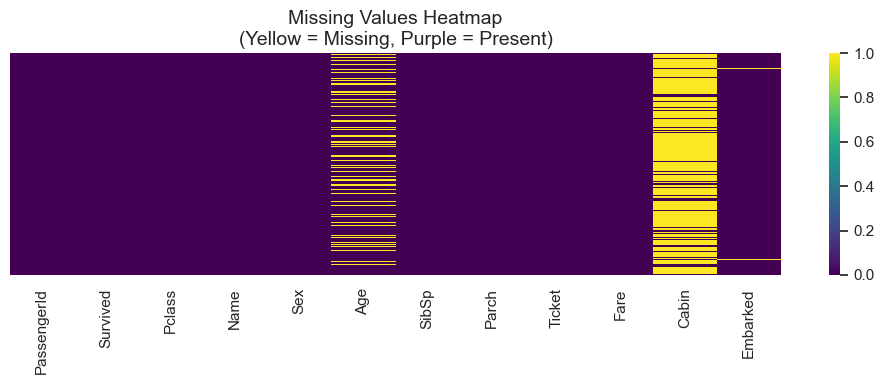

In [10]:
# Visualise missing values as a heatmap
# df.isnull() returns True where values are missing — we can plot that as a heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap\n(Yellow = Missing, Purple = Present)', fontsize=14)
plt.tight_layout()
plt.show()

# What do you notice? Write your observation as a comment below:
# OBSERVATION: 
# My observation is that the missing values are concentrated in the 'Age' and 'Cabin' columns.

---
## Part 3 — Visualisations

Data visualisation is how we build intuition about a dataset before modelling. 
We will create three key plots:
1. Age distribution (histogram)
2. Survival rate by gender (bar chart)
3. Correlation heatmap (numerical columns)

### 3.1 — Age Distribution Histogram

A histogram shows how values are distributed across bins. We use it to understand the shape of a numerical variable.

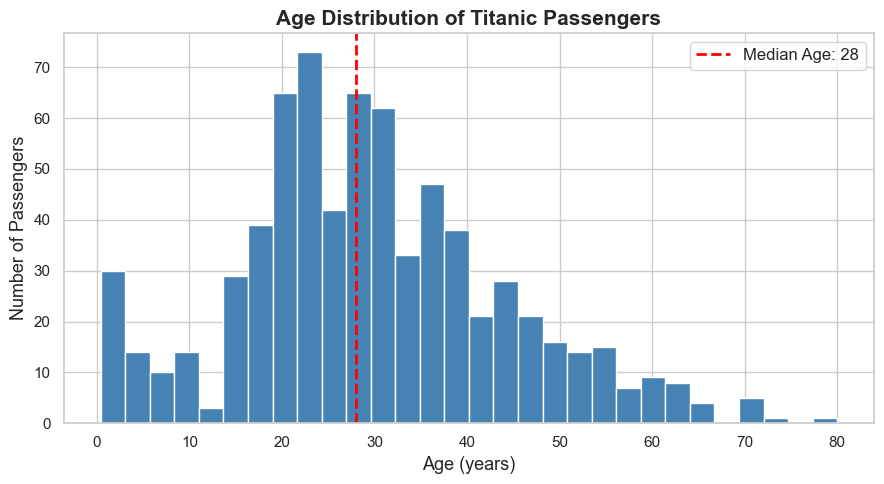

In [11]:
plt.figure(figsize=(9, 5))

# Plot a histogram of the 'Age' column
# HINT: Use plt.hist(df['Age'].dropna(), bins=30, color='steelblue', edgecolor='white')
# We use .dropna() because plt.hist cannot handle NaN values
plt.hist(df['Age'].dropna(), bins=30, color='steelblue', edgecolor='white')

# Add a vertical line at the median age
median_age = df['Age'].median()
plt.axvline(median_age, color='red', linestyle='--', linewidth=2, label=f'Median Age: {median_age:.0f}')

# Labels and formatting
plt.title('Age Distribution of Titanic Passengers', fontsize=15, fontweight='bold')
plt.xlabel('Age (years)', fontsize=13)
plt.ylabel('Number of Passengers', fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# After running: Is the distribution symmetric or skewed? Write your answer:
# ANSWER: 
# The distribution is skewed to the right.

### 3.2 — Survival Rate by Gender

This is one of the most famous patterns in the Titanic dataset: "women and children first" boarding policy.

We will calculate the survival rate per gender and visualise it as a bar chart.

Survival rates by gender:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64



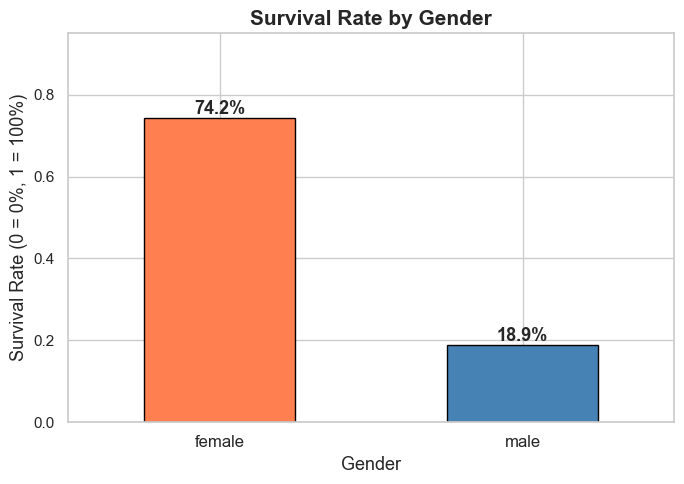

In [12]:
# Calculate the survival RATE (proportion, not count) grouped by gender
# HINT: Use df.groupby('Sex')['Survived'].mean()
# .mean() on a 0/1 column gives you the proportion of 1s = survival rate
survival_by_gender = df.groupby('Sex')['Survived'].mean()

print('Survival rates by gender:')
print(survival_by_gender.round(3))
print()

# Now create the bar chart
plt.figure(figsize=(7, 5))

# HINT: Use survival_by_gender.plot(kind='bar', color=['coral', 'steelblue'], edgecolor='black')
survival_by_gender.plot(kind='bar', color=['coral', 'steelblue'], edgecolor='black')

plt.title('Survival Rate by Gender', fontsize=15, fontweight='bold')
plt.xlabel('Gender', fontsize=13)
plt.ylabel('Survival Rate (0 = 0%, 1 = 100%)', fontsize=13)
plt.xticks(rotation=0, fontsize=12)

# Add value labels on top of each bar
for i, val in enumerate(survival_by_gender):
    plt.text(i, val + 0.01, f'{val:.1%}', ha='center', fontsize=13, fontweight='bold')

plt.ylim(0, 0.95)
plt.tight_layout()
plt.show()

### 3.3 — Survival Rate by Passenger Class

Let's look at another important variable: `Pclass` (1 = 1st class, 2 = 2nd class, 3 = 3rd class).

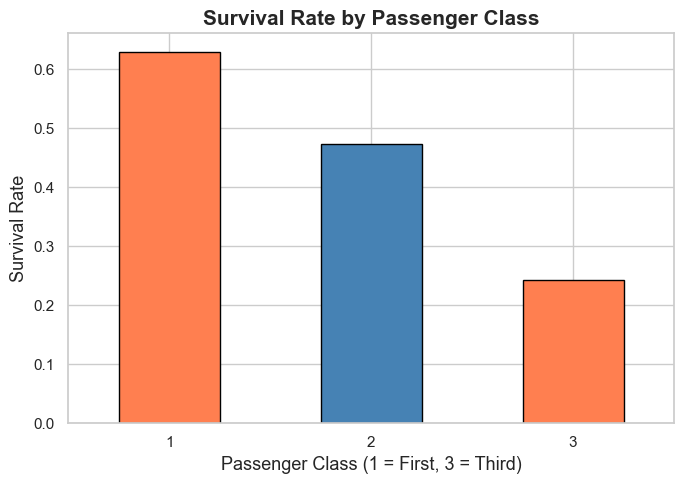

In [13]:
# Calculate survival rate grouped by passenger class
survival_by_class = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(7, 5))
# Plot a bar chart
survival_by_class.plot(kind='bar', color=['coral', 'steelblue'], edgecolor='black')

plt.title('Survival Rate by Passenger Class', fontsize=15, fontweight='bold')
plt.xlabel('Passenger Class (1 = First, 3 = Third)', fontsize=13)
plt.ylabel('Survival Rate', fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.4 — Correlation Heatmap

A correlation heatmap shows how numerically related all pairs of columns are.
- **+1.0** = perfect positive correlation (one goes up, other goes up)
- **-1.0** = perfect negative correlation (one goes up, other goes down)
- **0.0** = no linear relationship

For ML, we look for columns that correlate with our **target** (`Survived`).

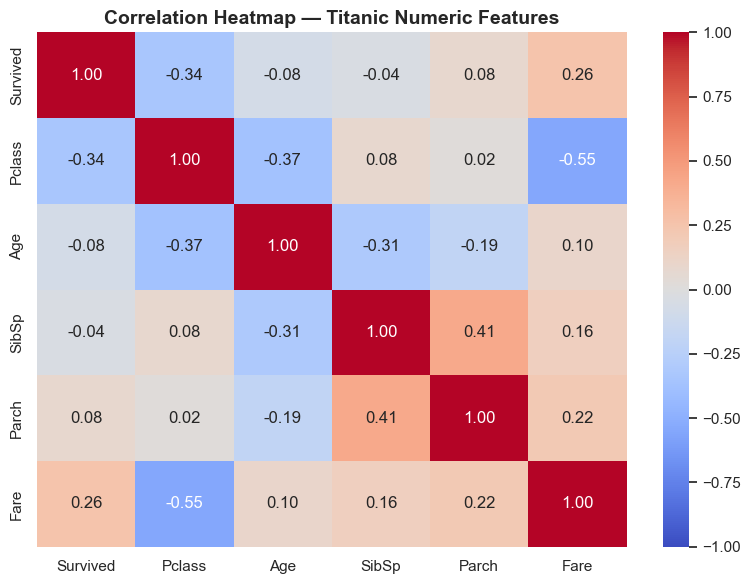

In [14]:
# Select only numeric columns for correlation
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

# Create the heatmap
# HINT: Use sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)

plt.title('Correlation Heatmap — Titanic Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# After running: Which feature has the strongest correlation with Survived?
# ANSWER: 
# Pclass has the strongest correlation with Survived.

# What does a negative correlation between Pclass and Survived mean in plain English?
# ANSWER: 
# A negative correlation between Pclass and Survived means that as Pclass increases, Survived decreases because Pclass low number means higher seat class.

---
## Part 4 — Data Cleaning & Preprocessing

Before we can use any ML model, we need to clean the data. We will:
1. Fill missing `Age` values with the **median** age
2. Fill missing `Embarked` values with the **mode** (most common port)
3. Drop the `Cabin` column (too many missing values — over 77%)
4. **Encode** the `Sex` column (convert text to numbers)
5. Drop columns we don't need (`Name`, `Ticket`, `PassengerId`)

### Why median and not mean for Age?
Because age is slightly right-skewed (a few very old passengers). The median is more robust to outliers than the mean.

In [15]:
# Make a copy so we don't accidentally modify the original
df_clean = df.copy()

# Step 1: Fill missing Age values with the median age
age_median = df_clean['Age'].median()
print(f'Median age: {age_median}')

# HINT: Use df_clean['Age'] = df_clean['Age'].fillna(age_median)
df_clean['Age'] = df_clean['Age'].fillna(age_median)

# Step 2: Fill missing Embarked with the mode (most common value)
embarked_mode = df_clean['Embarked'].mode()[0]   # mode() returns a Series, we take [0]
print(f'Most common Embarked port: {embarked_mode}')
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)

# Step 3: Drop the Cabin column (too many missing)
# HINT: Use df_clean.drop(columns=['Cabin'], inplace=True)
df_clean.drop(columns=['Cabin'], inplace=True)

# Step 4: Drop columns we won't use as features
cols_to_drop = ['Name', 'Ticket', 'PassengerId']
df_clean.drop(columns=cols_to_drop, inplace=True)

# Verify: no more missing values?
print(f'\nMissing values after cleaning:')
print(df_clean.isnull().sum())

Median age: 28.0
Most common Embarked port: S

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### 4.1 — Encoding the `Sex` column

Machine learning models work with numbers, not text. We need to convert `'male'` and `'female'` into numbers.

The simplest way for a binary column: **Label Encoding**
- `'female'` → 0  
- `'male'` → 1  

(Or we could use `pd.get_dummies()` for One-Hot Encoding — we'll see this more later)

### 4.2 — Final check: Value counts on key columns

In [16]:
# Check value counts for the target variable (Survived)
print('Survival counts:')
print(df_clean['Survived'].value_counts())
print()

# What percentage survived?
survival_rate = df_clean['Survived'].mean() * 100
print(f'Overall survival rate: {survival_rate:.1f}%')

# QUESTION: Is this dataset balanced (roughly 50/50) or imbalanced?
# ANSWER: The dataset is imbalanced. Only about 38.4% of passengers survived,
# while 61.6% did not survive. This is not a 50/50 split.

Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64

Overall survival rate: 38.4%


---
## Part 5 — Preparing for Machine Learning

Now that the data is clean, let's prepare it for an ML model:
1. Separate features (`X`) from the target (`y`)
2. Split into training and test sets

> **Note:** We won't train a model yet in this class; that will be done in the next section.  
> This is just the setup step that ends every EDA.

In [17]:
from sklearn.model_selection import train_test_split

# Step 1: Separate features and target
# X = everything except 'Survived'
# y = 'Survived' only
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

print(f'Features (X) shape: {X.shape}')
print(f'Target  (y) shape: {y.shape}')
print(f'Feature names: {list(X.columns)}')

Features (X) shape: (891, 7)
Target  (y) shape: (891,)
Feature names: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [18]:
# Step 2: Train/test split
# test_size=0.2 means 20% goes to test, 80% to training
# random_state=42 makes the split reproducible (same result every time)
# stratify=y ensures both train and test have the same survival ratio

# HINT: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set size : {X_train.shape[0]} rows')
print(f'Test set size     : {X_test.shape[0]} rows')
print(f'\nSurvival rate in train: {y_train.mean():.1%}')
print(f'Survival rate in test : {y_test.mean():.1%}')
print('(These should be very close — that is what stratify=y ensures)')

Training set size : 712 rows
Test set size     : 179 rows

Survival rate in train: 38.3%
Survival rate in test : 38.5%
(These should be very close — that is what stratify=y ensures)


---
## Part 6 — Your Findings 🔍

Can you calculate the survival rate for people who were travelling **alone** vs those with family?

Hint: A passenger is travelling alone if `SibSp == 0` AND `Parch == 0`.

Survival rate by travel status:
Alone
False    0.506
True     0.304
Name: Survived, dtype: float64



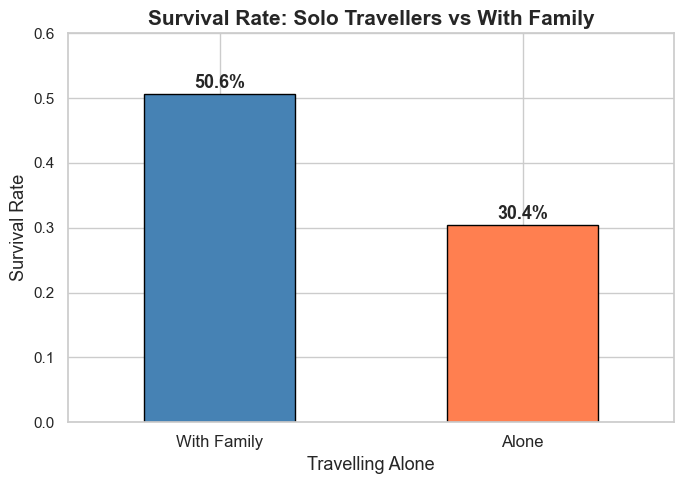

In [19]:
# Survival rate for solo travellers vs those with family
# Step 1: Create a new column 'Alone' that is True if SibSp==0 and Parch==0
df['Alone'] = (df['SibSp'] == 0) & (df['Parch'] == 0)

# Step 2: Group by 'Alone' and calculate mean survival rate
survival_by_alone = df.groupby('Alone')['Survived'].mean()
print('Survival rate by travel status:')
print(survival_by_alone.round(3))
print()

# Step 3: Plot the result
plt.figure(figsize=(7, 5))
survival_by_alone.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Survival Rate: Solo Travellers vs With Family', fontsize=15, fontweight='bold')
plt.xlabel('Travelling Alone', fontsize=13)
plt.ylabel('Survival Rate', fontsize=13)
plt.xticks([0, 1], ['With Family', 'Alone'], rotation=0, fontsize=12)
for i, val in enumerate(survival_by_alone):
    plt.text(i, val + 0.01, f'{val:.1%}', ha='center', fontsize=13, fontweight='bold')
plt.ylim(0, 0.6)
plt.tight_layout()
plt.show()

Create a plot showing how did the median fare price differs across passenger classes?

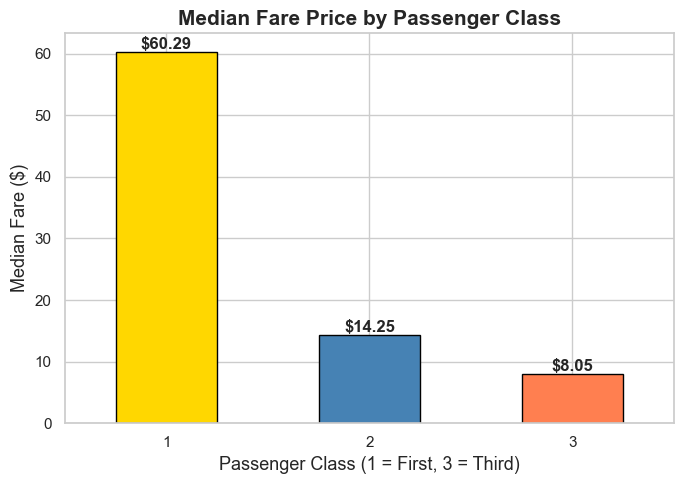

In [20]:
# Median fare price by passenger class
median_fare_by_class = df.groupby('Pclass')['Fare'].median()

plt.figure(figsize=(7, 5))
median_fare_by_class.plot(kind='bar', color=['gold', 'steelblue', 'coral'], edgecolor='black')

plt.title('Median Fare Price by Passenger Class', fontsize=15, fontweight='bold')
plt.xlabel('Passenger Class (1 = First, 3 = Third)', fontsize=13)
plt.ylabel('Median Fare ($)', fontsize=13)
plt.xticks(rotation=0)

for i, val in enumerate(median_fare_by_class):
    plt.text(i, val + 0.5, f'${val:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Create a plot showing showing the median age for each passenger class?

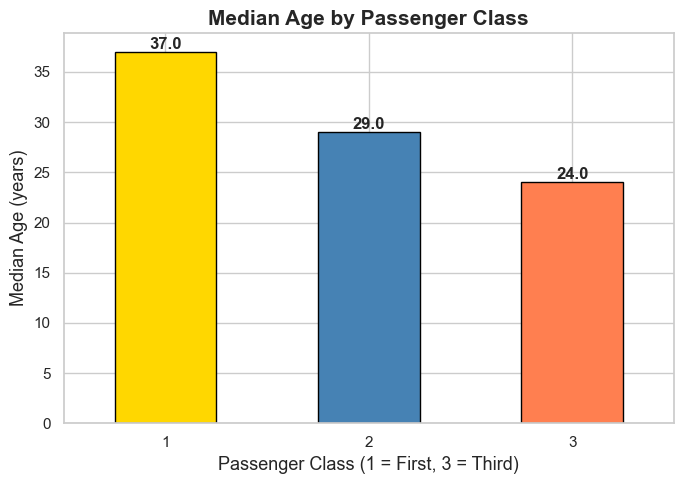

In [21]:
# Median age by passenger class
median_age_by_class = df.groupby('Pclass')['Age'].median()

plt.figure(figsize=(7, 5))
median_age_by_class.plot(kind='bar', color=['gold', 'steelblue', 'coral'], edgecolor='black')

plt.title('Median Age by Passenger Class', fontsize=15, fontweight='bold')
plt.xlabel('Passenger Class (1 = First, 3 = Third)', fontsize=13)
plt.ylabel('Median Age (years)', fontsize=13)
plt.xticks(rotation=0)

for i, val in enumerate(median_age_by_class):
    plt.text(i, val + 0.3, f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## ✅ Notebook Complete!

**What you practised today:**
- Loading a CSV with `pd.read_csv()`
- Inspecting data with `.info()`, `.describe()`, `.dtypes`
- Finding missing values with `.isnull().sum()`
- Plotting: histogram, bar chart, heatmap
- Cleaning: filling missing values, dropping columns, encoding categories
- Splitting data with `train_test_split()`

**This exact workflow — load → inspect → visualise → clean → split is the foundation of every ML project you will do in this course.**